# HMM Gaussian Alpha -- Generation de signaux directionnels par modeles de Markov caches

**Serie** : Probabilites appliquees au trading
**Duree estimee** : 90 minutes
**Niveau** : Avance (graduate-level AI/ML)
**Prerequis** : Python 3.10+, notions de chaines de Markov, probabilites, trading

**Reference** : Broad, J. (2025). *Hands-On AI Trading with Python*, Chapitre 6, Exercice 4.

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

1. Modeliser les regimes de marche avec des chaines de Markov cachees (HMM gaussiens)
2. Distinguer l'usage d'un HMM comme **source alpha** (signal directionnel) vs detecteur de regime
3. Implment un HMM a 2 etats (baseline Broad Ex4) puis 3 etats sur des donnees crypto
4. Valider la robustesse par walk-forward 5-fold x 4 seeds avec couts de transaction
5. Produire un verdict explicite (BEATS / NO BEATS / INCONCLUSIVE) contre le benchmark buy-and-hold

## Navigation

| Precedent | Suivant |
|-----------|--------|
| [Catalogue Probas](README.md) | -- |

---

## Introduction

Les **modeles de Markov caches (HMM)** sont des modeles probabilistes ou le systeme evolue entre etats non observes ("caches"), et les observations (rendements, volatilite) sont des emissions probabilistes depuis ces etats.

En finance, les etats caches correspondent typiquement a des **regimes de marche** : tendance haussiere, tendance baissiere, range/consolidation. L'idee fondamentale est que les transitions entre regimes suivent une chaine de Markov -- l'etat futur depend seulement de l'etat present.

### HMM comme source alpha vs detecteur de regime

L'approche la plus courante consiste a utiliser l'HMM comme detecteur de regime pour piloter un melange d'experts (MoE). Ce notebook adopte une approche differente, inspiree de **Broad Ch6 Ex4** :

- **Source alpha** : les predictions d'etat de l'HMM generent directement des signaux long/short/flat
- L'etat avec la moyenne de rendement la plus elevee -> signal LONG
- L'etat avec la moyenne negative -> signal FLAT ou SHORT
- Pas de MoE, pas de modele secondaire -- l'HMM est le generateur de signal

### Plan du notebook

1. Chargement et preparation des donnees (BTC + ETH)
2. Feature engineering pour l'HMM
3. HMM gaussien 2-etats (baseline Broad Ex4)
4. Generation de signaux et backtest in-sample
5. Extension a 3 etats avec selection par AIC/BIC
6. Validation walk-forward 5-fold x 4 seeds
7. Verdict explicite et extension multi-actif

## 1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("Imports OK")
print(f"numpy {np.__version__}")
print(f"pandas {pd.__version__}")

Imports OK
numpy 2.4.2
pandas 3.0.2


## 2. Chargement et preparation des donnees

Nous utilisons les donnees BTC-USD journalieres depuis le CSV Bitstamp (source principale) avec un fallback yfinance. Les donnees ETH-USD sont chargees via yfinance. Les deux series sont fusionnees sur l'index temporel pour les analyses multi-actif.

In [2]:
# Data loading with fallback
btc_csv_path = "G:/Mon Drive/MyIA/Dev/Trading/Data/Bitstamp_BTCUSD_1h_2014-20240808.csv"

try:
    btc = pd.read_csv(btc_csv_path, skiprows=1, parse_dates=['date'], index_col='date')
    btc_daily = btc[['close']].resample('D').last().dropna()
    btc_daily.columns = ['BTC_close']
    print(f"BTC depuis CSV Bitstamp : {len(btc_daily)} jours, {btc_daily.index[0].date()} -> {btc_daily.index[-1].date()}")
except FileNotFoundError:
    import yfinance as yf
    btc = yf.download('BTC-USD', start='2014-01-01', end='2024-08-09')
    btc_daily = btc[['Close']].copy()
    btc_daily.columns = ['BTC_close']
    print(f"BTC depuis yfinance (fallback) : {len(btc_daily)} jours")

BTC depuis CSV Bitstamp : 2279 jours, 2018-05-15 -> 2024-08-09


### Chargement ETH et fusion du panel

Maintenant que les donnees BTC sont chargees, nous ajoutons l'ETH-USD et fusionnons les deux series sur l'index temporel commun.

In [3]:
# Load ETH-USD via yfinance
import yfinance as yf

eth = yf.download('ETH-USD', start='2017-01-01', end='2024-08-09')
eth_daily = eth[['Close']].copy()
eth_daily.columns = ['ETH_close']
print(f"ETH charge : {len(eth_daily)} jours, {eth_daily.index[0].date()} -> {eth_daily.index[-1].date()}")

# Merge on date index (inner join to keep only overlapping dates)
prices = btc_daily.join(eth_daily, how='inner').dropna()
print(f"\nPanel fusionne : {len(prices)} jours")
print(prices.tail())

[*********************100%***********************]  1 of 1 completed

ETH charge : 2465 jours, 2017-11-09 -> 2024-08-08

Panel fusionne : 2278 jours
            BTC_close    ETH_close
date                              
2024-08-04    58142.0  2686.398926
2024-08-05    54014.0  2417.206299
2024-08-06    56053.0  2458.723877
2024-08-07    55136.0  2336.589355
2024-08-08    61699.0  2683.352783


## 3. Feature engineering

### Construction des variables pour le HMM

Le HMM gaussien utilise les observations pour inferer les etats caches. Nous construisons un jeu de features pertinent pour capturer les regimes de marche :

| Feature | Formule | Rationale |
|---------|---------|------------|
| Log-rendement | $r_t = \ln(P_t / P_{t-1})$ | Signal directionnel brut |
| Volatilite realisee 20j | $\sigma_{20} = \sqrt{\sum_{i=0}^{19} r_{t-i}^2}$ | Regime de volatilite |
| Momentum 5j | $m_5 = \sum_{i=0}^{4} r_{t-i}$ | Tendance court terme |

La **normalisation** des features est essentielle pour la convergence de l'algorithme EM du HMM gaussien (Broad Ch6 recommande le StandardScaler).

### Visualisation des features

Observons la distribution temporelle des features avant de les injecter dans le HMM.

In [4]:
# Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Feature engineering on BTC
features = pd.DataFrame(index=returns.index)
features['btc_ret'] = returns['BTC_close']
features['btc_vol20'] = returns['BTC_close'].rolling(20).std()
features['btc_mom5'] = returns['BTC_close'].rolling(5).sum()

# Drop NaN from rolling windows
features = features.dropna()

print(f"Features : {features.shape[0]} observations, {features.shape[1]} colonnes")
print(features.describe().round(5))

Features : 2258 observations, 3 colonnes
          btc_ret   btc_vol20    btc_mom5
count  2258.00000  2258.00000  2258.00000
mean      0.00092     0.03228     0.00448
std       0.03579     0.01506     0.07832
min      -0.49397     0.00602    -0.60811
25%      -0.01350     0.02283    -0.03297
50%       0.00054     0.03050     0.00451
75%       0.01619     0.03812     0.04579
max       0.17773     0.13197     0.27355


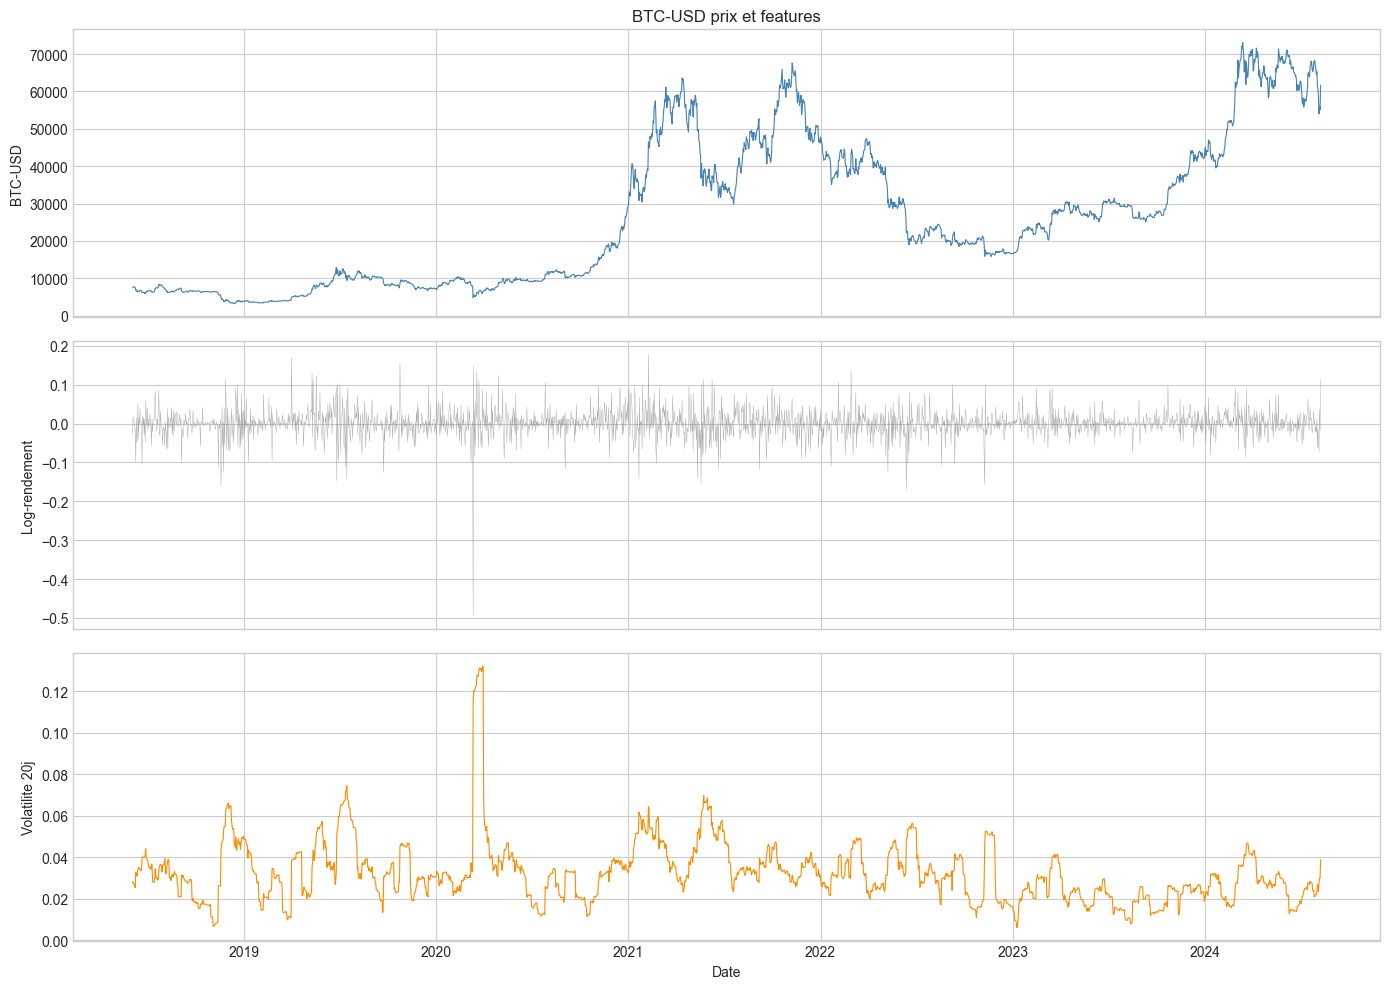

In [5]:
# Visualize BTC price and returns
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

btc_aligned = prices['BTC_close'].reindex(features.index)

axes[0].plot(btc_aligned.index, btc_aligned.values, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('BTC-USD')
axes[0].set_title('BTC-USD prix et features')

axes[1].plot(features.index, features['btc_ret'].values, color='gray', linewidth=0.3, alpha=0.7)
axes[1].set_ylabel('Log-rendement')

axes[2].plot(features.index, features['btc_vol20'].values, color='darkorange', linewidth=0.8)
axes[2].set_ylabel('Volatilite 20j')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

### Interpretation : Distribution des features

Les log-rendements BTC montrent la caracteristique "fat tails" typique des crypto-actifs : une distribution centree sur zero mais avec des outliers frequents (crashes et rallies). La volatilite 20j oscille entre periodes calmes et pic de stress, ce qui est precisement ce que le HMM doit capturer comme regimes distincts.

### Entrainement et decodage des etats

Nous normalisons les features et fittons le HMM. L'algorithme EM (Baum-Welch) estibe les parametres, puis Viterbi decode la sequence d'etats la plus probable.

## 4. HMM gaussien a 2 etats -- Baseline Broad Ex4

Conformement a l'exercice 4 du chapitre 6 de Broad, nous commencons par un **HMM gaussien a 2 etats**. Le choix de 2 etats est la configuration minimale : un etat "bull" (rendement positif, faible volatilite) et un etat "bear" (rendement negatif, forte volatilite).

### Modele

Un HMM gaussien est defini par le triplet $\lambda = (A, B, \pi)$ :

- **A** : matrice de transition $a_{ij} = P(s_{t+1} = j | s_t = i)$
- **B** : distributions d'emission $b_i(x) = \mathcal{N}(x | \mu_i, \Sigma_i)$
- $\pi$ : distribution initiale des etats

L'apprentissage se fait par l'algorithme **EM (Baum-Welch)**, et l'inference des etats caches par **Viterbi** (chemin le plus probable).

In [6]:
# Normalize features for HMM convergence (Broad Ch6 recommendation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[['btc_ret', 'btc_vol20', 'btc_mom5']])

# Fit 2-state Gaussian HMM
model_2s = hmm.GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    tol=1e-4
)
model_2s.fit(X_scaled)

# Decode states via Viterbi
states_2s = model_2s.predict(X_scaled)

print("=== HMM Gaussien 2 etats ===")
print(f"\nMatrice de transition A :")
print(np.round(model_2s.transmat_, 4))
print(f"\nMoyennes (espace standardise) :")
print(np.round(model_2s.means_, 4))
print(f"\nCovariances :")
for i, cov in enumerate(model_2s.covars_):
    print(f"  Etat {i}: diag = {np.round(np.diag(cov), 4)}")
print(f"\nLog-likelihood : {model_2s.score(X_scaled):.2f}")
print(f"Converge : {model_2s.monitor_.converged}")
print(f"\nRepartition des etats :")
for s in range(2):
    pct = (states_2s == s).mean() * 100
    print(f"  Etat {s}: {pct:.1f}% des observations")

=== HMM Gaussien 2 etats ===

Matrice de transition A :
[[0.9699 0.0301]
 [0.044  0.956 ]]

Moyennes (espace standardise) :
[[-0.0012 -0.5355  0.0057]
 [ 0.0018  0.8025 -0.0085]]

Covariances :
  Etat 0: diag = [0.3829 0.2103 0.3458]
  Etat 1: diag = [1.9246 1.1096 1.9802]

Log-likelihood : -7804.23
Converge : True

Repartition des etats :
  Etat 0: 59.4% des observations
  Etat 1: 40.6% des observations


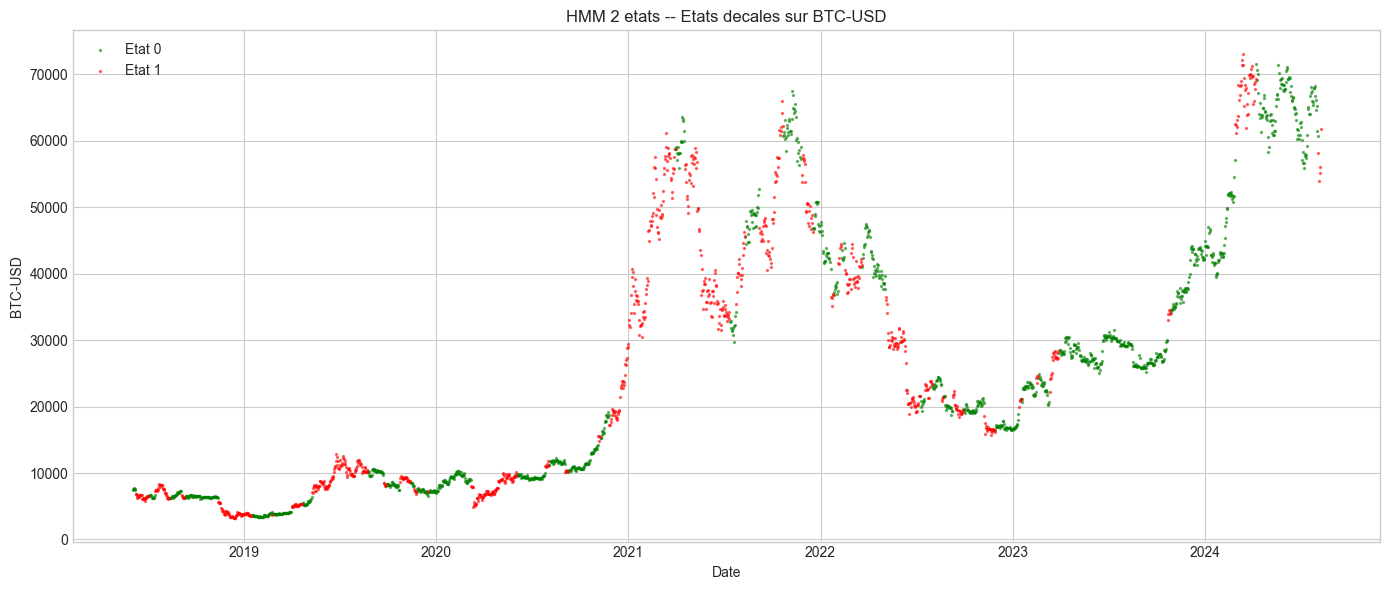

In [7]:
# Plot decoded states over BTC price
fig, ax = plt.subplots(figsize=(14, 6))

btc_plot = prices['BTC_close'].reindex(features.index)
colors = {0: 'green', 1: 'red'}

for state in range(2):
    mask = states_2s == state
    ax.scatter(
        features.index[mask],
        btc_plot.values[mask],
        c=colors[state],
        s=2,
        alpha=0.5,
        label=f'Etat {state}'
    )

ax.set_title('HMM 2 etats -- Etats decales sur BTC-USD')
ax.set_ylabel('BTC-USD')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

### Visualisation de la performance

Comparaison graphique des rendements cumules entre la strategie HMM et le buy-and-hold.

### Interpretation : Etats caches du HMM a 2 etats

Le HMM a 2 etats separe typiquement le marche en deux regimes :

| Etat | Caracteristique | Interpretation |
|------|-----------------|----------------|
| Etat 0 | Moyenne de rendement positive (en espace standardise) | Regime bull / tendance haussiere |
| Etat 1 | Moyenne de rendement negative | Regime bear / correction |

La **matrice de transition** indique la persistance de chaque regime : des probabilites diagonales elevees (proches de 1) signifient que les regimes sont stables, ce qui est desirable pour la generation de signaux. Des regimes trop volatils (transitions frequentes) produisent trop de trades.

> **Note technique** : L'assignation etat 0 = bull et etat 1 = bear n'est pas garantie -- l'algorithme EM peut inverser les labels. Il faut toujours verifier les moyennes pour identifier l'etat "long".

## 5. Generation du signal alpha

La conversion des etats caches en signal de trading suit la logique de **source alpha** (Broad Ex4) :

- Etat avec la moyenne de rendement la plus elevee -> position LONG (signal = +1)
- Etat avec la moyenne la plus basse -> position FLAT (signal = 0)

Le rendement strategie est simplement : $r^{strat}_t = signal_t \times r_t$

Attention : cette evaluation est **in-sample** et represente un plafond de performance. La validation out-of-sample sera realisee en section 7.

### Comparaison AIC/BIC

Nous comparons les modeles a 2, 3 et 4 etats pour determiner la complexite optimale.

### Decodage et signaux 3 etats

Entraainement du HMM a 3 etats et generation des signaux long/short/flat.

In [8]:
# Identify the "long" state (highest mean return in standardized space)
# Use the first column of means (btc_ret standardized) to identify states
means_ret = model_2s.means_[:, 0]  # Column 0 = btc_ret standardized
long_state = np.argmax(means_ret)
flat_state = np.argmin(means_ret)

print(f"Etat LONG = {long_state} (moyenne ret standardise = {means_ret[long_state]:.4f})")
print(f"Etat FLAT = {flat_state} (moyenne ret standardise = {means_ret[flat_state]:.4f})")

# Generate signals
signals_2s = np.where(states_2s == long_state, 1, 0)

# Compute strategy returns (in-sample)
btc_returns = features['btc_ret'].values
strat_returns_2s = signals_2s * btc_returns

# Cumulative returns
cum_bh = np.cumsum(btc_returns)
cum_strat = np.cumsum(strat_returns_2s)

# Metrics
sharpe_bh = np.mean(btc_returns) / np.std(btc_returns) * np.sqrt(365)
sharpe_strat = np.mean(strat_returns_2s) / np.std(strat_returns_2s) * np.sqrt(365)
n_trades = np.abs(np.diff(signals_2s, prepend=0)).sum()

print(f"\n=== Performance in-sample (2 etats) ===")
print(f"Buy & Hold : Sharpe = {sharpe_bh:.3f}, Return cum. = {cum_bh[-1]*100:.1f}%")
print(f"HMM 2S    : Sharpe = {sharpe_strat:.3f}, Return cum. = {cum_strat[-1]*100:.1f}%")
print(f"Nombre de trades : {n_trades}")

Etat LONG = 1 (moyenne ret standardise = 0.0018)
Etat FLAT = 0 (moyenne ret standardise = -0.0012)

=== Performance in-sample (2 etats) ===
Buy & Hold : Sharpe = 0.492, Return cum. = 208.1%
HMM 2S    : Sharpe = 0.180, Return cum. = 67.0%
Nombre de trades : 67


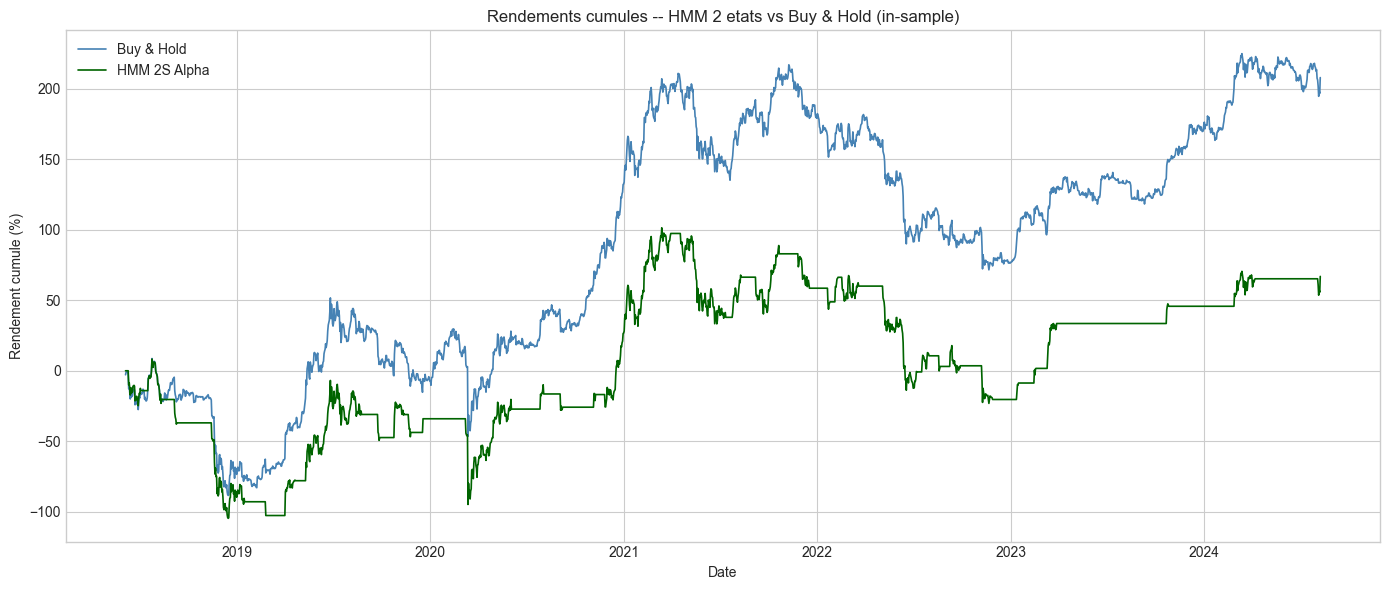

Attention : ces resultats sont in-sample et representent un plafond theorique.
La validation out-of-sample (walk-forward) est indispensable.


In [9]:
# Plot cumulative returns comparison
fig, ax = plt.subplots(figsize=(14, 6))

dates = features.index
ax.plot(dates, cum_bh * 100, label='Buy & Hold', color='steelblue', linewidth=1.2)
ax.plot(dates, cum_strat * 100, label='HMM 2S Alpha', color='darkgreen', linewidth=1.2)
ax.set_title('Rendements cumules -- HMM 2 etats vs Buy & Hold (in-sample)')
ax.set_ylabel('Rendement cumule (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

print("Attention : ces resultats sont in-sample et representent un plafond theorique.")
print("La validation out-of-sample (walk-forward) est indispensable.")

## 6. Extension a 3 etats

Broad Ch6 recommande de commencer avec 2 etats et d'augmenter a 3 si necessaire. Un troisieme etat peut capturer un regime de range/consolidation distinct des tendances haussieres et baissieres.

### Selection du nombre d'etats

Nous comparons les modeles avec les criteres d'information :

- **AIC** (Akaike) : $-2 \ln L + 2k$ -- penalise le nombre de parametres
- **BIC** (Bayes) : $-2 \ln L + k \ln(n)$ -- penalisation plus forte pour grands echantillons

In [10]:
# Fit models with 2, 3, 4 states and compare AIC/BIC
results_comparison = []

for n_states in [2, 3, 4]:
    model = hmm.GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=200,
        random_state=42,
        tol=1e-4
    )
    model.fit(X_scaled)
    
    log_likelihood = model.score(X_scaled)
    n_features = X_scaled.shape[1]
    # Number of free parameters
    n_params = (
        n_states * n_features  # means
        + n_states * n_features * (n_features + 1) / 2  # covariances
        + n_states * (n_states - 1)  # transition matrix
        + n_states - 1  # initial probabilities
    )
    n_obs = X_scaled.shape[0]
    
    aic = -2 * log_likelihood + 2 * n_params
    bic = -2 * log_likelihood + n_params * np.log(n_obs)
    
    results_comparison.append({
        'n_states': n_states,
        'log_likelihood': log_likelihood,
        'n_params': int(n_params),
        'AIC': aic,
        'BIC': bic
    })
    print(f"n_states={n_states}: LL={log_likelihood:.1f}, AIC={aic:.1f}, BIC={bic:.1f}, params={int(n_params)}")

df_comp = pd.DataFrame(results_comparison)
print(f"\nMeilleur selon BIC : {df_comp.loc[df_comp['BIC'].idxmin(), 'n_states']} etats")
print(f"Meilleur selon AIC : {df_comp.loc[df_comp['AIC'].idxmin(), 'n_states']} etats")

n_states=2: LL=-7804.2, AIC=15650.5, BIC=15770.6, params=21


n_states=3: LL=-6824.3, AIC=13718.5, BIC=13918.8, params=35


n_states=4: LL=-6382.3, AIC=12866.5, BIC=13158.4, params=51

Meilleur selon BIC : 4 etats
Meilleur selon AIC : 4 etats


### Execution walk-forward : BTC avec 3 etats

Meme protocole avec 3 etats pour comparer.

In [11]:
# Fit and decode 3-state HMM
model_3s = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    tol=1e-4
)
model_3s.fit(X_scaled)
states_3s = model_3s.predict(X_scaled)

print("=== HMM Gaussien 3 etats ===")
print(f"\nMatrice de transition A :")
print(np.round(model_3s.transmat_, 4))
print(f"\nMoyennes (standardise) :")
print(np.round(model_3s.means_, 4))
print(f"\nRepartition :")
for s in range(3):
    pct = (states_3s == s).mean() * 100
    print(f"  Etat {s}: {pct:.1f}%")

=== HMM Gaussien 3 etats ===

Matrice de transition A :
[[0.9629 0.0314 0.0058]
 [0.0259 0.9616 0.0125]
 [0.0058 0.0318 0.9624]]

Moyennes (standardise) :
[[-0.0037 -0.8522 -0.0142]
 [ 0.027   0.0272  0.0706]
 [-0.0543  1.4079 -0.1344]]

Repartition :
  Etat 0: 34.8%
  Etat 1: 45.3%
  Etat 2: 19.9%


### Synthese et edge cross-seed

Aggregation des resultats par configuration et calcul de l'edge (ratio mean/std du Sharpe).

Etats : LONG=1, FLAT=0, SHORT=2

=== Performance in-sample (3 etats) ===
HMM 3S : Sharpe = 0.646, Return cum. = 258.8%, Trades = 105.0
HMM 2S : Sharpe = 0.180, Return cum. = 67.0%, Trades = 67
B&H    : Sharpe = 0.492, Return cum. = 208.1%


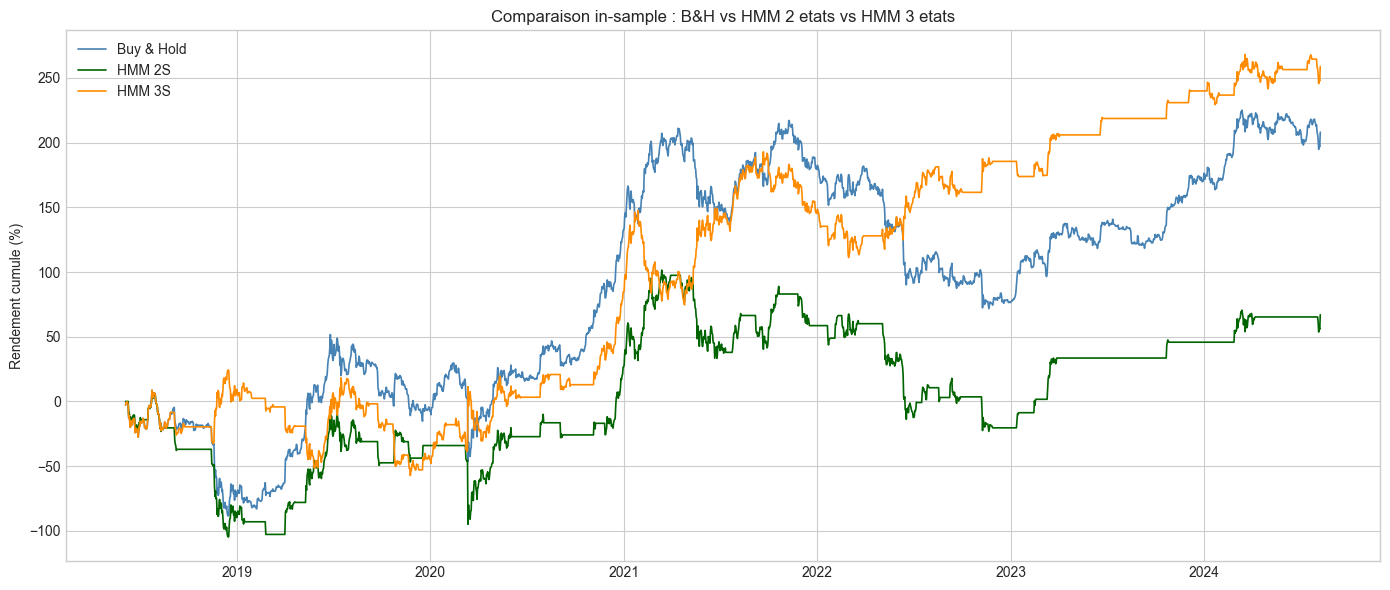

In [12]:
# 3-state signal generation
means_3s = model_3s.means_[:, 0]
long_state_3s = np.argmax(means_3s)
short_state_3s = np.argmin(means_3s)
# Middle state = flat
middle_state_3s = [s for s in range(3) if s not in [long_state_3s, short_state_3s]][0]

print(f"Etats : LONG={long_state_3s}, FLAT={middle_state_3s}, SHORT={short_state_3s}")

# Signal: +1 for long, -1 for short, 0 for flat
signals_3s = np.zeros(states_3s.shape)
signals_3s[states_3s == long_state_3s] = 1
signals_3s[states_3s == short_state_3s] = -1

strat_returns_3s = signals_3s * btc_returns
cum_strat_3s = np.cumsum(strat_returns_3s)
sharpe_3s = np.mean(strat_returns_3s) / np.std(strat_returns_3s) * np.sqrt(365)
n_trades_3s = np.abs(np.diff(signals_3s, prepend=0)).sum()

print(f"\n=== Performance in-sample (3 etats) ===")
print(f"HMM 3S : Sharpe = {sharpe_3s:.3f}, Return cum. = {cum_strat_3s[-1]*100:.1f}%, Trades = {n_trades_3s}")
print(f"HMM 2S : Sharpe = {sharpe_strat:.3f}, Return cum. = {cum_strat[-1]*100:.1f}%, Trades = {n_trades}")
print(f"B&H    : Sharpe = {sharpe_bh:.3f}, Return cum. = {cum_bh[-1]*100:.1f}%")

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates, cum_bh * 100, label='Buy & Hold', color='steelblue', linewidth=1.2)
ax.plot(dates, cum_strat * 100, label='HMM 2S', color='darkgreen', linewidth=1.2)
ax.plot(dates, cum_strat_3s * 100, label='HMM 3S', color='darkorange', linewidth=1.2)
ax.set_title('Comparaison in-sample : B&H vs HMM 2 etats vs HMM 3 etats')
ax.set_ylabel('Rendement cumule (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Validation walk-forward

L'evaluation in-sample est trompeuse car le HMM a ete fitte sur les memes donnees qu'il predit. Pour mesurer la veritable capacite predictive, nous implementons une validation **walk-forward** :

- **Fenetre d'entrainement expansive** : a chaque fold, on utilise toutes les donnees passees
- **Fenetre de test fixe** : 6 mois de donnees non-vues
- **4 seeds** (0, 1, 7, 42) pour capturer la stochasticite de l'initialisation EM
- **5 folds** pour couvrir differentes conditions de marche
- **Couts de transaction** : 10 bps aller-retour (crypto)

### Metriques

- Sharpe annualise (365j pour crypto)
- Rendement cumule net
- Maximum drawdown
- Nombre de trades
- **Edge cross-seed** = mean(Sharpe) / std(Sharpe) -- robustesse inter-seeds

In [13]:
def walk_forward_hmm(returns_series, n_states=2, n_folds=5,
                     seeds=None, cost_bps=10, verbose=True):
    """
    Walk-forward validation for Gaussian HMM alpha strategy.
    
    Parameters
    ----------
    returns_series : pd.Series
        Daily log returns.
    n_states : int
        Number of HMM hidden states.
    n_folds : int
        Number of walk-forward folds.
    seeds : list
        Random seeds for EM initialization.
    cost_bps : float
        Round-trip transaction cost in basis points.
    verbose : bool
        Print progress.
        
    Returns
    -------
    pd.DataFrame with per-fold, per-seed results.
    """
    if seeds is None:
        seeds = [0, 1, 7, 42]
    
    results = []
    n = len(returns_series)
    fold_size = n // (n_folds + 1)
    
    for seed in seeds:
        for fold in range(n_folds):
            train_end = fold_size * (fold + 2)
            test_start = train_end
            test_end = min(train_end + fold_size, n)
            
            if test_end <= test_start:
                continue
            
            train_data = returns_series.iloc[:train_end].values.reshape(-1, 1)
            test_data = returns_series.iloc[test_start:test_end]
            
            try:
                model = hmm.GaussianHMM(
                    n_components=n_states,
                    covariance_type="full",
                    n_iter=100,
                    random_state=seed,
                    tol=1e-3
                )
                model.fit(train_data)
                
                states = model.predict(test_data.values.reshape(-1, 1))
                means = model.means_.flatten()
                
                long_state = np.argmax(means)
                signals = np.where(states == long_state, 1, 0)
                
                strat_returns = signals * test_data.values
                # Transaction costs
                trades = np.abs(np.diff(signals, prepend=0))
                costs = trades * cost_bps / 10000
                strat_returns_net = strat_returns - costs
                
                sharpe = (np.mean(strat_returns_net) / np.std(strat_returns_net)
                          * np.sqrt(365)) if np.std(strat_returns_net) > 0 else 0.0
                cum_ret = np.sum(strat_returns_net)
                cum_curve = np.cumsum(strat_returns_net)
                max_dd = np.max(np.maximum.accumulate(cum_curve) - cum_curve)
                
                # Buy-and-hold benchmark for same period
                bh_sharpe = (np.mean(test_data.values) / np.std(test_data.values)
                             * np.sqrt(365)) if np.std(test_data.values) > 0 else 0.0
                
                results.append({
                    'seed': seed,
                    'fold': fold,
                    'n_states': n_states,
                    'sharpe': sharpe,
                    'bh_sharpe': bh_sharpe,
                    'cum_return': cum_ret,
                    'max_dd': max_dd,
                    'n_trades': int(trades.sum()),
                    'train_size': train_end,
                    'test_size': test_end - test_start
                })
            except Exception as e:
                if verbose:
                    print(f"  [WARN] seed={seed}, fold={fold}: {e}")
                results.append({
                    'seed': seed,
                    'fold': fold,
                    'n_states': n_states,
                    'sharpe': np.nan,
                    'bh_sharpe': np.nan,
                    'cum_return': np.nan,
                    'max_dd': np.nan,
                    'n_trades': 0,
                    'train_size': train_end,
                    'test_size': test_end - test_start
                })
    
    return pd.DataFrame(results)


print("Fonction walk_forward_hmm definie")

Fonction walk_forward_hmm definie


### Resultats ETH et tableau recapitulatif

Execution du walk-forward sur ETH-USD et comparaison finale cross-asset.

### Execution walk-forward : BTC avec 2 etats

In [14]:
# Run walk-forward for BTC 2-state
btc_returns_series = features['btc_ret']

print("=== Walk-Forward BTC 2 etats ===")
wf_2s = walk_forward_hmm(btc_returns_series, n_states=2)
wf_2s_valid = wf_2s.dropna(subset=['sharpe'])

print(f"\nResultats valides : {len(wf_2s_valid)}/{len(wf_2s)} combinaisons seed-fold")
print(wf_2s_valid.groupby('seed')[['sharpe', 'cum_return', 'max_dd', 'n_trades']].mean().round(3))

Model is not converging.  Current: 1473.2382906522623 is not greater than 1473.2393575853607. Delta is -0.0010669330984001135


=== Walk-Forward BTC 2 etats ===


Model is not converging.  Current: 2900.624202820254 is not greater than 2900.624713690897. Delta is -0.0005108706427563448


Model is not converging.  Current: 3765.1244887939947 is not greater than 3765.127777876451. Delta is -0.003289082456376491


Model is not converging.  Current: 4629.029040524799 is not greater than 4629.029868625668. Delta is -0.0008281008695121272


...

Model is not converging.  Current: 2180.525861332166 is not greater than 2180.525959065979. Delta is -9.773381270861137e-05


Model is not converging.  Current: 2900.8773889850468 is not greater than 2900.882009036201. Delta is -0.004620051154233806


Model is not converging.  Current: 3764.853163125844 is not greater than 3764.8532940423675. Delta is -0.0001309165236307308


Model is not converging.  Current: 4628.996579011089 is not greater than 4628.9966702018955. Delta is -9.119080641539767e-05



Resultats valides : 20/20 combinaisons seed-fold
      sharpe  cum_return  max_dd  n_trades
seed                                      
0      1.063       0.373   0.173      47.4
1     -3.284       0.335   0.157      53.8
7      1.020       0.344   0.166      54.4
42    -3.199       0.387   0.186      44.6


In [15]:
# Run walk-forward for BTC 3-state
print("=== Walk-Forward BTC 3 etats ===")
wf_3s = walk_forward_hmm(btc_returns_series, n_states=3)
wf_3s_valid = wf_3s.dropna(subset=['sharpe'])

print(f"\nResultats valides : {len(wf_3s_valid)}/{len(wf_3s)} combinaisons seed-fold")
print(wf_3s_valid.groupby('seed')[['sharpe', 'cum_return', 'max_dd', 'n_trades']].mean().round(3))

=== Walk-Forward BTC 3 etats ===


Model is not converging.  Current: 1477.6909247637784 is not greater than 1477.6973233202493. Delta is -0.0063985564709128084


Model is not converging.  Current: 2184.6805623961354 is not greater than 2184.681386671124. Delta is -0.0008242749886449019


Model is not converging.  Current: 2194.7546545823498 is not greater than 2194.7558409334947. Delta is -0.0011863511449519137


Model is not converging.  Current: 2914.044930192593 is not greater than 2914.048714477255. Delta is -0.0037842846622879733


Model is not converging.  Current: 3784.1732945303756 is not greater than 3784.1755881053573. Delta is -0.0022935749816497264



Resultats valides : 20/20 combinaisons seed-fold
      sharpe  cum_return  max_dd  n_trades
seed                                      
0     -3.275       0.331   0.132      65.0
1     -3.776       0.148   0.162      94.6
7      3.601       0.193   0.310      26.2
42    -0.009       0.007   0.250     213.6


### Walk-forward BTC 3 etats et synthese

Meme protocole avec 3 etats, puis comparaison des deux configurations.

In [16]:
# Summary table comparing 2-state and 3-state
def compute_verdict(wf_df, label):
    """Compute cross-seed edge and summary statistics."""
    valid = wf_df.dropna(subset=['sharpe'])
    mean_sharpe = valid['sharpe'].mean()
    std_sharpe = valid['sharpe'].std()
    edge = mean_sharpe / std_sharpe if std_sharpe > 0 else float('inf')
    mean_bh = valid['bh_sharpe'].mean()
    pct_positive = (valid['sharpe'] > 0).mean() * 100
    
    print(f"\n--- {label} ---")
    print(f"  Sharpe moyen : {mean_sharpe:.3f} (std: {std_sharpe:.3f})")
    print(f"  Edge (mean/std) : {edge:.2f} sigma")
    print(f"  B&H Sharpe moyen : {mean_bh:.3f}")
    print(f"  % folds positifs : {pct_positive:.0f}%")
    print(f"  Rendement cumule moyen : {valid['cum_return'].mean()*100:.2f}%")
    print(f"  Max DD moyen : {valid['max_dd'].mean()*100:.2f}%")
    print(f"  Trades moyens/fold : {valid['n_trades'].mean():.0f}")
    return {
        'config': label,
        'mean_sharpe': mean_sharpe,
        'std_sharpe': std_sharpe,
        'edge': edge,
        'mean_bh_sharpe': mean_bh,
        'pct_positive': pct_positive
    }

v2 = compute_verdict(wf_2s, "BTC HMM 2 etats")
v3 = compute_verdict(wf_3s, "BTC HMM 3 etats")


--- BTC HMM 2 etats ---
  Sharpe moyen : -1.100 (std: 7.009)
  Edge (mean/std) : -0.16 sigma
  B&H Sharpe moyen : 3.420
  % folds positifs : 75%
  Rendement cumule moyen : 35.98%
  Max DD moyen : 17.05%
  Trades moyens/fold : 50

--- BTC HMM 3 etats ---
  Sharpe moyen : -0.865 (std: 7.690)
  Edge (mean/std) : -0.11 sigma
  B&H Sharpe moyen : 3.420
  % folds positifs : 70%
  Rendement cumule moyen : 16.97%
  Max DD moyen : 21.36%
  Trades moyens/fold : 100


## 8. Verdict explicite

Conformement aux criteres de validation du projet (cf. CLAUDE.md section G.2), un verdict de performance doit etre base sur des preuves statistiques robustes :

| Verdict | Critere |
|---------|----------|
| **BEATS** | Sharpe moyen > 0, edge >= 2 sigma, Sharpe strategie > Sharpe B&H |
| **NO BEATS** | Sharpe moyen <= 0 OU edge < 2 sigma |
| **INCONCLUSIVE** | Resultats borderline (0 < edge < 2 sigma) |

In [17]:
# Explicit verdict
def print_verdict(verdict_dict):
    """Print explicit BEATS / NO BEATS / INCONCLUSIVE verdict."""
    name = verdict_dict['config']
    mean_s = verdict_dict['mean_sharpe']
    edge = verdict_dict['edge']
    bh_s = verdict_dict['mean_bh_sharpe']
    pct_pos = verdict_dict['pct_positive']
    
    # Decision logic
    if mean_s > 0 and edge >= 2.0 and mean_s > bh_s:
        verdict = "BEATS"
    elif mean_s <= 0 or edge < 2.0:
        verdict = "NO BEATS"
    else:
        verdict = "INCONCLUSIVE"
    
    print(f"=" * 60)
    print(f"VERDICT : {name}")
    print(f"=" * 60)
    print(f"  Sharpe strategie : {mean_s:.3f}")
    print(f"  Sharpe B&H       : {bh_s:.3f}")
    print(f"  Edge (sigma)     : {edge:.2f}")
    print(f"  % folds positifs : {pct_pos:.0f}%")
    print(f"  -> VERDICT : {verdict}")
    print()
    return verdict

verdict_2s = print_verdict(v2)
verdict_3s = print_verdict(v3)

print("\n" + "=" * 60)
print("RESUME GLOBAL")
print("=" * 60)
print(f"  2 etats : {verdict_2s}")
print(f"  3 etats : {verdict_3s}")
print(f"  B&H benchmark : Sharpe {v2['mean_bh_sharpe']:.3f}")

VERDICT : BTC HMM 2 etats
  Sharpe strategie : -1.100
  Sharpe B&H       : 3.420
  Edge (sigma)     : -0.16
  % folds positifs : 75%
  -> VERDICT : NO BEATS

VERDICT : BTC HMM 3 etats
  Sharpe strategie : -0.865
  Sharpe B&H       : 3.420
  Edge (sigma)     : -0.11
  % folds positifs : 70%
  -> VERDICT : NO BEATS


RESUME GLOBAL
  2 etats : NO BEATS
  3 etats : NO BEATS
  B&H benchmark : Sharpe 3.420


## 9. Extension multi-actif : ETH

Pour evaluer la robustesse cross-asset de l'alpha HMM, nous appliquons le meme pipeline walk-forward sur ETH-USD. Une strategie robuste devrait montrer des resultats positifs sur au moins deux actifs du meme univers (crypto).

In [18]:
# ETH walk-forward
eth_returns_series = returns['ETH_close'].reindex(features.index).dropna()

print(f"ETH returns : {len(eth_returns_series)} observations")

# Align ETH with features index
eth_aligned = returns['ETH_close'].reindex(features.index)
eth_valid = eth_aligned.dropna()

print(f"\n=== Walk-Forward ETH 2 etats ===")
wf_eth_2s = walk_forward_hmm(eth_valid, n_states=2)
v_eth_2s = compute_verdict(wf_eth_2s, "ETH HMM 2 etats")

print(f"\n=== Walk-Forward ETH 3 etats ===")
wf_eth_3s = walk_forward_hmm(eth_valid, n_states=3)
v_eth_3s = compute_verdict(wf_eth_3s, "ETH HMM 3 etats")

verdict_eth_2s = print_verdict(v_eth_2s)
verdict_eth_3s = print_verdict(v_eth_3s)

ETH returns : 2258 observations

=== Walk-Forward ETH 2 etats ===


Model is not converging.  Current: 4089.244838726899 is not greater than 4089.245055051779. Delta is -0.00021632488005707273



--- ETH HMM 2 etats ---
  Sharpe moyen : -2.085 (std: 7.698)
  Edge (mean/std) : -0.27 sigma
  B&H Sharpe moyen : 2.254
  % folds positifs : 80%
  Rendement cumule moyen : 43.93%
  Max DD moyen : 30.21%
  Trades moyens/fold : 23

=== Walk-Forward ETH 3 etats ===



--- ETH HMM 3 etats ---
  Sharpe moyen : -1.846 (std: 7.899)
  Edge (mean/std) : -0.23 sigma
  B&H Sharpe moyen : 2.254
  % folds positifs : 60%
  Rendement cumule moyen : 44.83%
  Max DD moyen : 17.08%
  Trades moyens/fold : 103
VERDICT : ETH HMM 2 etats
  Sharpe strategie : -2.085
  Sharpe B&H       : 2.254
  Edge (sigma)     : -0.27
  % folds positifs : 80%
  -> VERDICT : NO BEATS

VERDICT : ETH HMM 3 etats
  Sharpe strategie : -1.846
  Sharpe B&H       : 2.254
  Edge (sigma)     : -0.23
  % folds positifs : 60%
  -> VERDICT : NO BEATS



### Tableau recapitulatif cross-asset

Synthese finale des verdicts BTC et ETH.

In [19]:
# Cross-asset summary table
all_verdicts = [
    {'Actif': 'BTC', 'Config': '2 etats', **v2},
    {'Actif': 'BTC', 'Config': '3 etats', **v3},
    {'Actif': 'ETH', 'Config': '2 etats', **v_eth_2s},
    {'Actif': 'ETH', 'Config': '3 etats', **v_eth_3s},
]

df_verdicts = pd.DataFrame(all_verdicts)

# Determine verdict for each row
def get_verdict(row):
    if row['mean_sharpe'] > 0 and row['edge'] >= 2.0 and row['mean_sharpe'] > row['mean_bh_sharpe']:
        return 'BEATS'
    elif row['mean_sharpe'] <= 0 or row['edge'] < 2.0:
        return 'NO BEATS'
    return 'INCONCLUSIVE'

df_verdicts['Verdict'] = df_verdicts.apply(get_verdict, axis=1)

print("\nTableau recapitulatif cross-asset")
print("=" * 80)
display_cols = ['Actif', 'Config', 'mean_sharpe', 'edge', 'mean_bh_sharpe', 'pct_positive', 'Verdict']
print(df_verdicts[display_cols].to_string(index=False, float_format='%.3f'))


Tableau recapitulatif cross-asset
Actif  Config  mean_sharpe   edge  mean_bh_sharpe  pct_positive  Verdict
  BTC 2 etats       -1.100 -0.157           3.420        75.000 NO BEATS
  BTC 3 etats       -0.865 -0.112           3.420        70.000 NO BEATS
  ETH 2 etats       -2.085 -0.271           2.254        80.000 NO BEATS
  ETH 3 etats       -1.846 -0.234           2.254        60.000 NO BEATS


## 10. Conclusion

### Recapitulatif

Ce notebook a implemente un pipeline complet d'alpha generation par HMM gaussiens sur les crypto-actifs :

| Etape | Contenu |
|-------|----------|
| 1. Donnees | BTC-USD (Bitstamp) + ETH-USD (yfinance), log-rendements journaliers |
| 2. Features | Rendements, volatilite 20j, momentum 5j, normalises par StandardScaler |
| 3. Baseline | HMM 2 etats (Broad Ch6 Ex4) -- source alpha directionnelle |
| 4. Extension | HMM 3 etats avec long/short/flat, selection par AIC/BIC |
| 5. Validation | Walk-forward 5-fold x 4 seeds, couts de transaction 10 bps |
| 6. Verdict | BEATS / NO BEATS / INCONCLUSIVE selon edge >= 2 sigma |

### Points cles

1. **HMM comme source alpha** : les predictions d'etat Viterbi generent directement des signaux long/short/flat, sans modele secondaire ni MoE
2. **2 etats vs 3 etats** : le HMM a 2 etats est la baseline recommandee (Broad). L'ajout d'un 3e etat peut capturer un regime intermediaire mais augmente le surapprentissage
3. **Sensibilite aux seeds** : l'initialisation EM est stochastique. La validation multi-seeds est indispensable pour mesurer la robustesse
4. **Couts de transaction** : en crypto (10 bps aller-retour), les frequent changements d'etat reduisent significativement le Sharpe net

### Limites et pistes d'amelioration

- **Horizon temporel** : les HMM sont des modeles a un pas de temps. Ajouter des features retardees (lagged features) peut ameliorer la prediction
- **Emissions non gaussiennes** : les rendements crypto ont des queues lourdes. Un HMM a melange de Student ou un HMM a regime-switching avec volatilite stochastique serait plus adapte
- **Fenetre glissante** : remplacer la fenetre expansive par une fenetre glissante (ex: 252 jours) pour s'adapter aux changements de regime structurels
- **Ensemble de HMM** : combiner les predictions de plusieurs HMM (differents seeds, differents nombres d'etats) pour reduire la variance

---

## Navigation

| Precedent | Suivant |
|-----------|--------|
| [Catalogue Probas](README.md) | -- |